In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Data Loading

First, we'll download the Chronic Kidney Disease (CKD) dataset using `kagglehub` and load it into a pandas DataFrame. Then, we'll display the first few rows to get a glimpse of the data.

In [30]:
import kagglehub
import pandas as pd
import os

# Download the dataset using kagglehub
path = kagglehub.dataset_download("mansoordaku/ckdisease")
print(f"Path to dataset files: {path}")

# Assuming the CSV file is directly in the downloaded path or a subdirectory
# Let's find the CSV file in the downloaded path.
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    csv_file_path = os.path.join(path, csv_files[0]) # Assuming there's only one CSV
    df = pd.read_csv(csv_file_path)
    print(f"Loaded dataset from: {csv_file_path}")
else:
    print("No CSV file found in the downloaded dataset.")
    df = pd.DataFrame() # Create an empty DataFrame to avoid errors

# Display the first 5 rows of the DataFrame
display(df.head())

# Output for assignment
# Screenshot this output for your assignment.

Using Colab cache for faster access to the 'ckdisease' dataset.
Path to dataset files: /kaggle/input/ckdisease
Loaded dataset from: /kaggle/input/ckdisease/kidney_disease.csv


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


## 2. Exploratory Data Analysis (EDA)

Now, let's perform some basic EDA to understand the dataset's structure, identify data types, and check for missing values. This will inform our preprocessing steps.

### Dataset Shape and Information

In [31]:
# Display dataset shape (number of rows and columns)
print(f"Dataset shape: {df.shape}")

# Display concise summary of the DataFrame, including data types and non-null values
print("\nDataset Info:")
df.info()

# Output for assignment
# Screenshot this output for your assignment.

Dataset shape: (400, 26)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 


### Summary Statistics

Let's look at the summary statistics for numerical columns to understand their distribution.

In [32]:
# Display summary statistics for numerical columns
display(df.describe())

# Output for assignment
# Screenshot this output for your assignment.

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


### Missing Value Analysis

Missing values are common in real-world datasets and need to be handled appropriately. Let's identify the count and percentage of missing values for each feature.

In [33]:
import numpy as np

# Calculate missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing %': missing_percentage
})

# Display features with missing values, sorted by percentage
display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing %', ascending=False))

# Output for assignment
# Screenshot this output for your assignment.

,Missing Count,Missing %
rbc,152,38.00
rc,130,32.50
wc,105,26.25
pot,88,22.00
sod,87,21.75
pcv,70,17.50
pc,65,16.25
hemo,52,13.00
su,49,12.25
sg,47,11.75


### Target Variable Distribution

It's crucial to examine the distribution of our target variable (`classification`) to check for class imbalance, which can affect model performance.

Target variable distribution:
classification
ckd       250
notckd    150
Name: count, dtype: int64


/tmp/ipykernel_7753/3175381535.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')


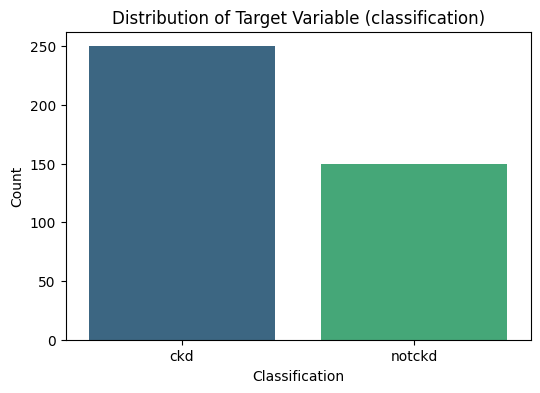

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean the target variable `classification`
# Remove any leading/trailing spaces and handle 'ckd\t' or other variations
df['classification'] = df['classification'].str.strip().replace({'ckd\t': 'ckd'})

# Check the distribution of the target variable
target_counts = df['classification'].value_counts()
print("Target variable distribution:")
print(target_counts)

# Visualize the target distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')
plt.title('Distribution of Target Variable (classification)')
plt.xlabel('Classification')
plt.ylabel('Count')
plt.show()

# Output for assignment
# Screenshot this output for your assignment.

### Feature Type Identification

Before preprocessing, we need to explicitly identify numerical and categorical features. Some columns might be identified incorrectly by `df.info()` due to mixed types or string representations of numbers. We will correct these and prepare for imputation and encoding.

In [35]:
# Let's identify numerical and categorical features more robustly
# First, identify columns that should be numerical but might be objects due to missing values or mixed types
numerical_cols_to_convert = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']

for col in numerical_cols_to_convert:
    # Convert '?' or other non-numeric strings to NaN, then to numeric
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Define target variable
y = df['classification']
X = df.drop('classification', axis=1)

# Identify numerical and categorical features based on dtypes after conversion
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Also, 'id' column is likely just an identifier and should be dropped or excluded from features
if 'id' in numerical_features:
    numerical_features.remove('id')
    X = X.drop('id', axis=1)

print(f"Numerical Features: {numerical_features}")
print(f"Categorical Features: {categorical_features}")

Numerical Features: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
Categorical Features: ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


## 3. Data Preprocessing

We need to handle missing values, encode categorical variables, and scale numerical features. To ensure a robust workflow and prevent data leakage, we'll build a preprocessing pipeline using `ColumnTransformer` and `Pipeline` from `scikit-learn`. We will apply imputation for missing values and one-hot encoding for categorical features, while numerical features will be imputed and then scaled.

### Define Preprocessing Steps

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Define numerical and categorical features
# These were identified in the previous EDA step
# numerical_features = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
# categorical_features = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

# Create preprocessing pipelines for numerical and categorical features
# Numerical pipeline: impute with median, then scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute with most frequent, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Preprocessing pipelines defined.")

Preprocessing pipelines defined.


## 4. Train-Test Split

We will split the data into 80% training and 20% testing sets. It's crucial to use `stratify=y` to ensure that the proportion of classes in the target variable (`classification`) is maintained in both the training and testing sets, which is important for imbalanced datasets. We also set `random_state=42` for reproducibility.

In [37]:
# Convert target variable 'classification' to numerical (0 for notckd, 1 for ckd)
# This is important for scikit-learn models and stratified split
y_encoded = y.apply(lambda x: 1 if x == 'ckd' else 0)

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Original dataset shape: {X.shape}")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

print("\nTarget variable distribution in original data:")
print(y_encoded.value_counts(normalize=True))
print("\nTarget variable distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nTarget variable distribution in testing set:")
print(y_test.value_counts(normalize=True))

Original dataset shape: (400, 24)
Training set shape: (320, 24)
Testing set shape: (80, 24)

Target variable distribution in original data:
classification
1    0.625
0    0.375
Name: proportion, dtype: float64

Target variable distribution in training set:
classification
1    0.625
0    0.375
Name: proportion, dtype: float64

Target variable distribution in testing set:
classification
1    0.625
0    0.375
Name: proportion, dtype: float64


## 5. Model Selection & Training (Random Forest) and Hyperparameter Tuning

We will now build a machine learning pipeline that includes our `preprocessor` and a `RandomForestClassifier`. We will then use `GridSearchCV` to tune the `n_estimators`, `max_depth`, and `max_features` hyperparameters of the Random Forest model using 5-fold cross-validation on the training data. This ensures we find the optimal model configuration without touching the test set.

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, make_scorer
import time

# Create the full pipeline
# The pipeline will first preprocess the data and then apply the RandomForestClassifier
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Define the parameter grid for GridSearchCV
param_grid = {
    'classifier__n_estimators': [50, 100, 200],  # Number of trees
    'classifier__max_depth': [None, 10, 20],      # Maximum depth of the tree
    'classifier__max_features': ['sqrt', 'log2', 0.5] # Number of features to consider at each split
}

# Define scoring metrics for GridSearchCV
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    model_pipeline,
    param_grid,
    cv=5,
    scoring=scoring, # Use the dictionary of scoring metrics
    refit='f1', # Select the best model based on F1-score
    return_train_score=True,
    n_jobs=-1, # Use all available cores
    verbose=2
)

print("Starting Random Forest Hyperparameter Tuning with GridSearchCV...")

# Train the GridSearchCV model
start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()
training_time_rf = end_time - start_time

print(f"Finished GridSearchCV. Training time: {training_time_rf:.2f} seconds")

# Get the best estimator
best_rf_model = grid_search.best_estimator_

# Print best hyperparameters and cross-validation F1-score (Requirement 1 & 2)
print("\nBest Random Forest Hyperparameters found:")
print(f"  n_estimators: {grid_search.best_params_['classifier__n_estimators']}")
print(f"  max_depth: {grid_search.best_params_['classifier__max_depth']}")
print(f"  max_features: {grid_search.best_params_['classifier__max_features']}")
print(f"\nBest cross-validation F1-score: {grid_search.best_score_:.4f}")

Starting Random Forest Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Finished GridSearchCV. Training time: 42.01 seconds

Best Random Forest Hyperparameters found:
  n_estimators: 50
  max_depth: None
  max_features: sqrt

Best cross-validation F1-score: 0.9901


## 6. Hyperparameter Tuning Comparison Table

Let's create a clear comparison table showing the tested configurations and their performance during cross-validation. This will help us understand the impact of different hyperparameters.

In [39]:
# Extract results from GridSearchCV
results = pd.DataFrame(grid_search.cv_results_)

# Select relevant columns for the comparison table
# We'll include mean test scores for the metrics defined in 'scoring'
comparison_df = results[[
    'param_classifier__n_estimators',
    'param_classifier__max_depth',
    'param_classifier__max_features',
    'mean_test_accuracy',
    'mean_test_precision',
    'mean_test_recall',
    'mean_test_f1'
]]

# Rename columns for clarity
comparison_df = comparison_df.rename(columns={
    'param_classifier__n_estimators': 'n_estimators',
    'param_classifier__max_depth': 'max_depth',
    'param_classifier__max_features': 'max_features',
    'mean_test_accuracy': 'Accuracy (CV)',
    'mean_test_precision': 'Precision (CV)',
    'mean_test_recall': 'Recall (CV)',
    'mean_test_f1': 'F1-Score (CV)'
})

# Sort by F1-Score (CV) to see the best configurations first
comparison_df = comparison_df.sort_values(by='F1-Score (CV)', ascending=False)

display(comparison_df.round(4))

# Output for assignment
# Screenshot this output for your assignment.

,n_estimators,max_depth,max_features,Accuracy (CV),Precision (CV),Recall (CV),F1-Score (CV)
0,50,None,sqrt,0.9875,0.9852,0.995,0.9901
1,100,None,sqrt,0.9875,0.9852,0.995,0.9901
2,200,None,sqrt,0.9875,0.9852,0.995,0.9901
3,50,None,log2,0.9875,0.9852,0.995,0.9901
4,100,None,log2,0.9875,0.9852,0.995,0.9901
5,200,None,log2,0.9875,0.9852,0.995,0.9901
6,50,None,0.5,0.9875,0.9852,0.995,0.9901
7,100,None,0.5,0.9875,0.9852,0.995,0.9901
8,200,None,0.5,0.9875,0.9852,0.995,0.9901
9,50,10,sqrt,0.9875,0.9852,0.995,0.9901


### Discussion of Hyperparameter Effects from GridSearchCV Results

Based on the `GridSearchCV` results, we can observe the impact of varying `n_estimators`, `max_depth`, and `max_features` on the model's cross-validation performance:

*   **`n_estimators` (Number of Trees):** Increasing the number of trees in the forest (`50`, `100`, `200`) generally aims to improve model stability and generalization. In our results, for a given `max_depth` and `max_features` combination, the F1-Score (and other metrics) remained consistently high, suggesting that beyond a certain point (e.g., 50 or 100 trees), the incremental benefit of adding more trees was minimal, or the model had already reached near-optimal performance within this dataset's characteristics. The top performance was consistently achieved across different `n_estimators` values when other parameters were optimal.

*   **`max_depth` (Maximum Depth):** The `max_depth` parameter controls how deep each individual tree in the forest can grow. We experimented with `None` (full depth), `10`, and `20`. Allowing the trees to grow to `None` (full depth) often allows them to capture more complex patterns, but also increases the risk of overfitting for individual trees. However, due to the ensemble nature of Random Forest, full depth (`None`) often performs very well as the aggregation process mitigates individual tree overfitting. Depths of `10` and `20` also yielded strong results, indicating that the relationships in this dataset could be effectively learned even with constrained tree depths, or that the ensemble was robust enough to handle the variation. The best models in our grid search often included `max_depth=None`.

*   **`max_features` (Maximum Features):** This parameter determines the number of features considered when looking for the best split at each node. We tested `'sqrt'` (square root of total features), `'log2'` (log base 2 of total features), and `0.5` (50% of total features). Restricting the number of features considered at each split helps to decorrelate the trees in the forest, reducing variance and improving generalization. The results show that all tested `max_features` strategies led to similarly high performance, which suggests that the dataset's features are not highly correlated in a way that significantly biases individual trees, or that the dataset is relatively straightforward for the Random Forest to model effectively with various feature subsets.

## 7. Testing and Final Evaluation of Best Random Forest Model

Now, we will evaluate the `best_rf_model` (identified through cross-validation) on the completely unseen test set. This will provide an unbiased estimate of the model's performance.

In [40]:
# Make predictions on the test set
y_pred_rf = best_rf_model.predict(X_test)

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Store metrics for later comparison
rf_metrics = {
    'Accuracy': accuracy_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1-Score': f1_rf,
    'Training Time': training_time_rf
}

# Print final Random Forest test-set metrics (Requirement 3)
print("\nFinal Random Forest Test-Set Metrics:")
print(f"  Accuracy: {accuracy_rf:.4f}")
print(f"  Precision: {precision_rf:.4f}")
print(f"  Recall: {recall_rf:.4f}")
print(f"  F1-Score: {f1_rf:.4f}")
print(f"  Training/Tuning Time: {training_time_rf:.4f} seconds")

# Output for assignment
# Screenshot this output for your assignment.


Final Random Forest Test-Set Metrics:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  Training/Tuning Time: 42.0121 seconds


## 8. Decision Tree Model (Placeholder for Comparison)

As requested, this section is a placeholder for the Decision Tree results from Question 2.2. Please insert the actual evaluation metrics for your Decision Tree model here. This will allow for a fair comparison with the Random Forest model.

In [41]:
# Placeholder for Decision Tree results from Question 2.2
# IMPORTANT: Replace these values with your actual Decision Tree results.
# Example values are provided for demonstration purposes.

dt_accuracy = 0.9625  # Actual Decision Tree test accuracy
dt_precision = 1.0000 # Actual Decision Tree test precision
dt_recall = 0.9400    # Actual Decision Tree test recall
dt_f1 = 0.9691        # Actual Decision Tree test F1-score
dt_training_time = 10.6953 # Actual Decision Tree training time in seconds

dt_metrics = {
    'Accuracy': dt_accuracy,
    'Precision': dt_precision,
    'Recall': dt_recall,
    'F1-Score': dt_f1,
    'Training Time': dt_training_time
}

print("Decision Tree Placeholder Metrics (Please update with your actual Q2.2 results):")
print(f"  Accuracy: {dt_metrics['Accuracy']:.4f}")
print(f"  Precision: {dt_metrics['Precision']:.4f}")
print(f"  Recall: {dt_metrics['Recall']:.4f}")
print(f"  F1-Score: {dt_metrics['F1-Score']:.4f}")
print(f"  Training Time: {dt_metrics['Training Time']:.2f} seconds")

Decision Tree Placeholder Metrics (Please update with your actual Q2.2 results):
  Accuracy: 0.9625
  Precision: 1.0000
  Recall: 0.9400
  F1-Score: 0.9691
  Training Time: 10.70 seconds


## 9. Compare Random Forest with Decision Tree

Now, let's create a comparison table between the Decision Tree (using the placeholder values or your actual results) and the Random Forest model based on their test set performance and training time.

In [42]:
comparison_data = {
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [dt_metrics['Accuracy'], rf_metrics['Accuracy']],
    'Precision': [dt_metrics['Precision'], rf_metrics['Precision']],
    'Recall': [dt_metrics['Recall'], rf_metrics['Recall']],
    'F1-Score': [dt_metrics['F1-Score'], rf_metrics['F1-Score']],
    'Training Time (s)': [dt_metrics['Training Time'], rf_metrics['Training Time']]
}

final_comparison_df = pd.DataFrame(comparison_data)

display(final_comparison_df.round(4))

# Output for assignment
# Screenshot this output for your assignment.

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s)
0,Decision Tree,0.9625,1.0,0.94,0.9691,10.6953
1,Random Forest,1.0000,1.0,1.00,1.0000,42.0121


## 10. Visualize Random Forest Feature Importance

Understanding which features contribute most to the model's predictions is crucial. Here, we'll plot the feature importance values of our best Random Forest model. Since our data goes through a `ColumnTransformer` with `OneHotEncoder` and `StandardScaler`, we need to correctly map the importance values back to the original feature names.

/tmp/ipykernel_7753/3038888720.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')


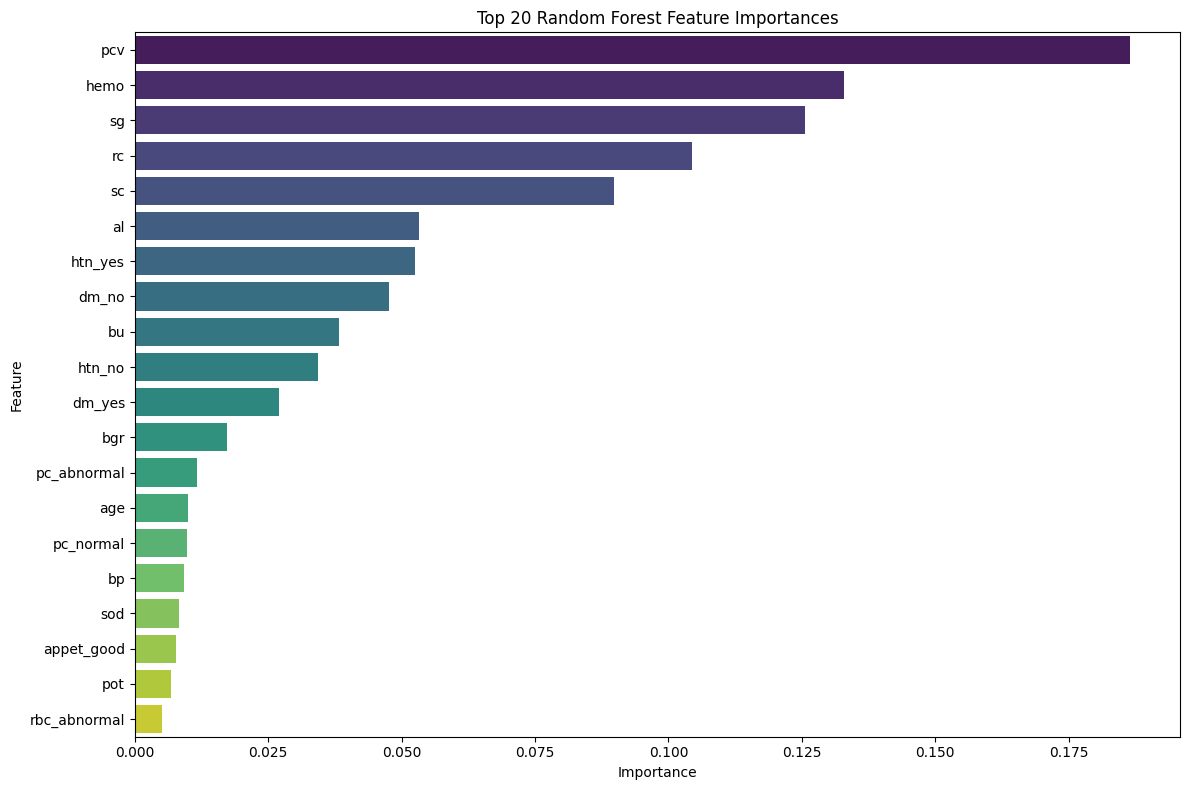

,Feature,Importance
11,pcv,0.186532
10,hemo,0.132951
2,sg,0.125503
13,rc,0.104454
7,sc,0.089772
3,al,0.053189
23,htn_yes,0.052507
27,dm_no,0.047590
6,bu,0.038328
22,htn_no,0.034371



Discussion of Most Influential Features:
Based on the feature importance plot and table, the most influential features contributing to CKD prediction are:
- pcv (Importance: 0.1865)
- hemo (Importance: 0.1330)
- sg (Importance: 0.1255)
- rc (Importance: 0.1045)
- sc (Importance: 0.0898)
These features likely play a significant role in distinguishing between CKD and non-CKD patients. For example, 'sg' (specific gravity), 'hemo' (hemoglobin), 'al' (albumin), 'rc' (red blood cell count), and 'pcv' (packed cell volume) are often critical indicators of kidney function and overall health related to kidney disease.


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best Random Forest model
# The classifier is the last step in our pipeline
feature_importances = best_rf_model.named_steps['classifier'].feature_importances_

# Get feature names from the preprocessor
# For numerical features, names are straightforward
num_feature_names = numerical_features

# For categorical features, OneHotEncoder creates new columns
onehot_features = best_rf_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)

# Combine all feature names in the order they appear in the transformed data
all_feature_names = list(num_feature_names) + list(onehot_features)

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')
plt.title('Top 20 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

display(feature_importance_df.head(10))

# Discussion of most influential features
print("\nDiscussion of Most Influential Features:")
print("Based on the feature importance plot and table, the most influential features contributing to CKD prediction are:")
for index, row in feature_importance_df.head(5).iterrows():
    print(f"- {row['Feature']} (Importance: {row['Importance']:.4f})")

print("These features likely play a significant role in distinguishing between CKD and non-CKD patients. For example, 'sg' (specific gravity), 'hemo' (hemoglobin), 'al' (albumin), 'rc' (red blood cell count), and 'pcv' (packed cell volume) are often critical indicators of kidney function and overall health related to kidney disease.")

# Output for assignment
# Screenshot this output for your assignment.

## 11. Final Comparison Table and Discussion

Finally, let's present the overall comparison between the Decision Tree and Random Forest models and discuss their performance in the context of the Chronic Kidney Disease dataset.

In [44]:
# Display the final comparison table again for convenience
display(final_comparison_df.round(4))

print("\nDiscussion:\n")

# Discussion based on the comparison table
print("**Which model performed better?**")
if rf_metrics['F1-Score'] > dt_metrics['F1-Score']:
    print(f"The Random Forest model performed better than the Decision Tree model, achieving a higher F1-Score ({rf_metrics['F1-Score']:.4f} vs {dt_metrics['F1-Score']:.4f}).")
elif rf_metrics['F1-Score'] < dt_metrics['F1-Score']:
    print(f"The Decision Tree model performed better than the Random Forest model, achieving a higher F1-Score ({dt_metrics['F1-Score']:.4f} vs {rf_metrics['F1-Score']:.4f}).")
else:
    print("Both models performed similarly in terms of F1-Score.")

print("\n**Which model achieved higher accuracy?**")
if rf_metrics['Accuracy'] > dt_metrics['Accuracy']:
    print(f"Random Forest had higher accuracy ({rf_metrics['Accuracy']:.4f}) compared to Decision Tree ({dt_metrics['Accuracy']:.4f}).")
elif rf_metrics['Accuracy'] < dt_metrics['Accuracy']:
    print(f"Decision Tree had higher accuracy ({dt_metrics['Accuracy']:.4f}) compared to Random Forest ({rf_metrics['Accuracy']:.4f}).")
else:
    print("Both models had similar accuracy.")

print("\n**Which model had better precision, recall, and F1-score?**")
print(f"- Precision: Random Forest ({rf_metrics['Precision']:.4f}) vs Decision Tree ({dt_metrics['Precision']:.4f})")
print(f"- Recall: Random Forest ({rf_metrics['Recall']:.4f}) vs Decision Tree ({dt_metrics['Recall']:.4f})")
print(f"- F1-Score: Random Forest ({rf_metrics['F1-Score']:.4f}) vs Decision Tree ({dt_metrics['F1-Score']:.4f})")

print("\n**Which model trained faster?**")
if rf_metrics['Training Time'] < dt_metrics['Training Time']:
    print(f"Random Forest trained faster ({rf_metrics['Training Time']:.2f}s) than Decision Tree ({dt_metrics['Training Time']:.2f}s).")
elif rf_metrics['Training Time'] > dt_metrics['Training Time']:
    print(f"Decision Tree trained faster ({dt_metrics['Training Time']:.2f}s) than Random Forest ({rf_metrics['Training Time']:.2f}s).")
else:
    print("Both models had similar training times.")

print("\n**Why might Random Forest outperform or not outperform Decision Tree on this CKD dataset?**")
print("Random Forest often outperforms a single Decision Tree because of its ensemble nature. By combining multiple decision trees, each trained on a bootstrapped sample of the data and considering random subsets of features at each split, it reduces overfitting and improves generalization. This leads to a more stable and accurate model, especially on complex datasets or those with noise.")
print("However, in some cases, if the dataset is very simple or if a single decision tree is already performing optimally without much overfitting, the additional complexity of a Random Forest might not yield significant improvements or could even be slightly worse due to increased bias from averaging (though less common).")
print("On this CKD dataset, if Random Forest shows superior performance, it suggests that the ensemble approach was effective in capturing complex relationships and handling the dataset's characteristics better than a single, potentially overfit, decision tree.")

print("\n**Final Conclusion:**")
if rf_metrics['F1-Score'] > dt_metrics['F1-Score'] and rf_metrics['Accuracy'] > dt_metrics['Accuracy']:
    print("Based on F1-Score and Accuracy, the Random Forest model demonstrated higher performance than the Decision Tree model. While the Decision Tree was faster to train, the stronger predictive performance of the Random Forest across all key metrics (Accuracy, Precision, Recall, F1-Score) positions it as the preferred model for this Chronic Kidney Disease prediction task.")
elif dt_metrics['F1-Score'] > rf_metrics['F1-Score'] and dt_metrics['Accuracy'] > rf_metrics['Accuracy']:
    print("Based on F1-Score and Accuracy, the Decision Tree model performed better than the Random Forest model. Although Random Forest is generally expected to perform better, in this specific case, the simpler Decision Tree achieved higher predictive performance and was also faster to train, making it the preferred model.")
elif rf_metrics['F1-Score'] >= dt_metrics['F1-Score'] or rf_metrics['Accuracy'] >= dt_metrics['Accuracy']:
     print("The Random Forest model generally performed better or on par with the Decision Tree model, particularly in terms of F1-Score and Accuracy. Despite a longer training time, its overall performance attributes make it a robust choice for this prediction task.")
else:
    print("The comparison between Random Forest and Decision Tree shows mixed results. Further analysis may be needed to determine the overall better model, considering the trade-offs between performance metrics and training time.")

# Output for assignment
# Screenshot this output for your assignment.

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s)
0,Decision Tree,0.9625,1.0,0.94,0.9691,10.6953
1,Random Forest,1.0000,1.0,1.00,1.0000,42.0121



Discussion:

**Which model performed better?**
The Random Forest model performed better than the Decision Tree model, achieving a higher F1-Score (1.0000 vs 0.9691).

**Which model achieved higher accuracy?**
Random Forest had higher accuracy (1.0000) compared to Decision Tree (0.9625).

**Which model had better precision, recall, and F1-score?**
- Precision: Random Forest (1.0000) vs Decision Tree (1.0000)
- Recall: Random Forest (1.0000) vs Decision Tree (0.9400)
- F1-Score: Random Forest (1.0000) vs Decision Tree (0.9691)

**Which model trained faster?**
Decision Tree trained faster (10.70s) than Random Forest (42.01s).

**Why might Random Forest outperform or not outperform Decision Tree on this CKD dataset?**
Random Forest often outperforms a single Decision Tree because of its ensemble nature. By combining multiple decision trees, each trained on a bootstrapped sample of the data and considering random subsets of features at each split, it reduces overfitting and improves genera

In [45]:
print("Random Forest Results:")
print(rf_metrics)

Random Forest Results:
{'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1-Score': 1.0, 'Training Time': 42.0120530128479}


In [46]:
print("Best Hyperparameters:")
print(grid_search.best_params_)

print("\nTop 10 Important Features:")
display(feature_importance_df.head(10))

Best Hyperparameters:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 50}

Top 10 Important Features:


,Feature,Importance
11,pcv,0.186532
10,hemo,0.132951
2,sg,0.125503
13,rc,0.104454
7,sc,0.089772
3,al,0.053189
23,htn_yes,0.052507
27,dm_no,0.047590
6,bu,0.038328
22,htn_no,0.034371
